# Hedge Ratio Dinámico: Filtro de Kalman vs. OLS Estático

Compara el enfoque estándar de `01_Cointegration_Analysis.ipynb` (hedge ratio OLS, fijo sobre toda la muestra) contra un **Filtro de Kalman en espacio de estados** (`kalman_pairs.py`) que deja que el hedge ratio derive día a día, más el modelo de costos de transacción/slippage asimétrico agregado a `pairs_trading_engine.py`.

Todo lo que sigue corre sobre datos reales de Binance descargados en el momento -- nada está precalculado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pairs_trading_engine import (
    SYMBOLS, N_CANDLES,
    fetch_price_panel, screen_pairs_for_cointegration,
    estimate_hedge_ratio, compute_spread, rolling_zscore,
    generate_signals, backtest_spread_strategy, compute_transaction_cost_returns,
)
from kalman_pairs import run_kalman_hedge_ratio, DEFAULT_DELTA, R_EWM_LAMBDA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Datos y selección de par

Mismo universo y mismo criterio de selección que `01_Cointegration_Analysis.ipynb` (el par con el p-value de Engle-Granger más bajo) -- así la comparación OLS-vs-Kalman de abajo es sobre el mismo par, no uno elegido para favorecer a uno de los dos métodos.

In [2]:
panel = fetch_price_panel(SYMBOLS, n_candles=N_CANDLES)
screening = screen_pairs_for_cointegration(panel)
best = screening.iloc[0]
Y_SYMBOL, X_SYMBOL = best["y"], best["x"]

print(f"{len(panel)} dias: {panel.index.min().date()} -> {panel.index.max().date()}")
print(f"Par seleccionado: {Y_SYMBOL}/{X_SYMBOL} (Engle-Granger p={best['eg_pvalue']:.4f})")

log_y = np.log(panel[Y_SYMBOL])
log_x = np.log(panel[X_SYMBOL])

  descargando BTCUSDT (1d, 1000 velas)...


  descargando ETHUSDT (1d, 1000 velas)...


  descargando SOLUSDT (1d, 1000 velas)...


  descargando BNBUSDT (1d, 1000 velas)...


  descargando XRPUSDT (1d, 1000 velas)...


1000 dias: 2023-12-02 -> 2026-08-27
Par seleccionado: BNBUSDT/XRPUSDT (Engle-Granger p=0.0299)


## 2. Ecuaciones del Filtro de Kalman

Estado (camino aleatorio, sin dinámica determinista):

$$\theta_t = \begin{bmatrix}\alpha_t \\ \beta_t\end{bmatrix}, \qquad \theta_t = \theta_{t-1} + w_t, \quad w_t \sim N(0, Q)$$

Observación:

$$y_t = F_t \theta_t + v_t, \qquad F_t = [1, x_t], \quad v_t \sim N(0, R_t)$$

Recursión (predicción + actualización, una vez por día):

$$\theta_{t|t-1} = \theta_{t-1|t-1}, \qquad P_{t|t-1} = P_{t-1|t-1} + Q$$
$$e_t = y_t - F_t \theta_{t|t-1} \quad (\text{= el spread}), \qquad S_t = F_t P_{t|t-1} F_t^\top + R_t$$
$$K_t = P_{t|t-1} F_t^\top / S_t, \qquad \theta_{t|t} = \theta_{t|t-1} + K_t e_t, \qquad P_{t|t} = (I - K_t F_t) P_{t|t-1}$$

El z-score sale directo de la propia recursión, sin ventana rolling: $z_t = e_t / \sqrt{S_t}$.

$R_t$ se actualiza cada paso vía EWMA de $e_t^2$ (no queda fijo desde un burn-in -- ver `kalman_pairs.py` para el hallazgo real que motivó esto: con $R$ fijo, el z-score quedaba mal calibrado y casi nunca cruzaba el umbral de entrada).

In [3]:
print(f"delta (velocidad de adaptacion de theta): {DEFAULT_DELTA}")
print(f"lambda EWMA de R (2/(30+1), misma ventana que ROLLING_ZSCORE_WINDOW): {R_EWM_LAMBDA:.4f}")

delta (velocidad de adaptacion de theta): 0.0001
lambda EWMA de R (2/(30+1), misma ventana que ROLLING_ZSCORE_WINDOW): 0.0645


## 3. Backtest: OLS estático vs. Kalman dinámico

Ambos con el mismo modelo de costos de transacción (`include_costs=True` por defecto): fee tipo taker (10bps) más slippage asimétrico -- 5bps al entrar (evento de cola, libro más fino), 2bps al salir (régimen ya calmo).

In [4]:
# --- OLS estatico (baseline) ---
hedge = estimate_hedge_ratio(log_y, log_x)
spread_ols = compute_spread(log_y, log_x, hedge)
zscore_ols = rolling_zscore(spread_ols)
positions_ols = generate_signals(zscore_ols)
bt_ols = backtest_spread_strategy(panel[Y_SYMBOL], panel[X_SYMBOL], hedge.beta, positions_ols)

# --- Kalman dinamico ---
kf = run_kalman_hedge_ratio(log_y, log_x)
positions_kf = generate_signals(kf.zscore)
bt_kf = backtest_spread_strategy(panel[Y_SYMBOL], panel[X_SYMBOL], kf.beta, positions_kf)

comparison = pd.DataFrame({
    "OLS (estatico)": {
        "beta": hedge.beta, "retorno neto": bt_ols.total_return, "retorno bruto": bt_ols.total_return_gross,
        "sharpe": bt_ols.annualized_sharpe, "max_drawdown": bt_ols.max_drawdown,
        "trades": bt_ols.n_trades, "costo_total": bt_ols.total_transaction_cost,
    },
    "Kalman (dinamico)": {
        "beta": kf.beta.iloc[-1], "retorno neto": bt_kf.total_return, "retorno bruto": bt_kf.total_return_gross,
        "sharpe": bt_kf.annualized_sharpe, "max_drawdown": bt_kf.max_drawdown,
        "trades": bt_kf.n_trades, "costo_total": bt_kf.total_transaction_cost,
    },
}).T
comparison

,beta,retorno neto,retorno bruto,sharpe,max_drawdown,trades,costo_total
OLS (estatico),0.300678,-0.437286,-0.371895,-0.373187,-0.516419,21.0,0.1110
Kalman (dinamico),0.418071,-0.122211,-0.059054,-0.308647,-0.213508,13.0,0.0702


## 4. Beta: fijo vs. adaptativo

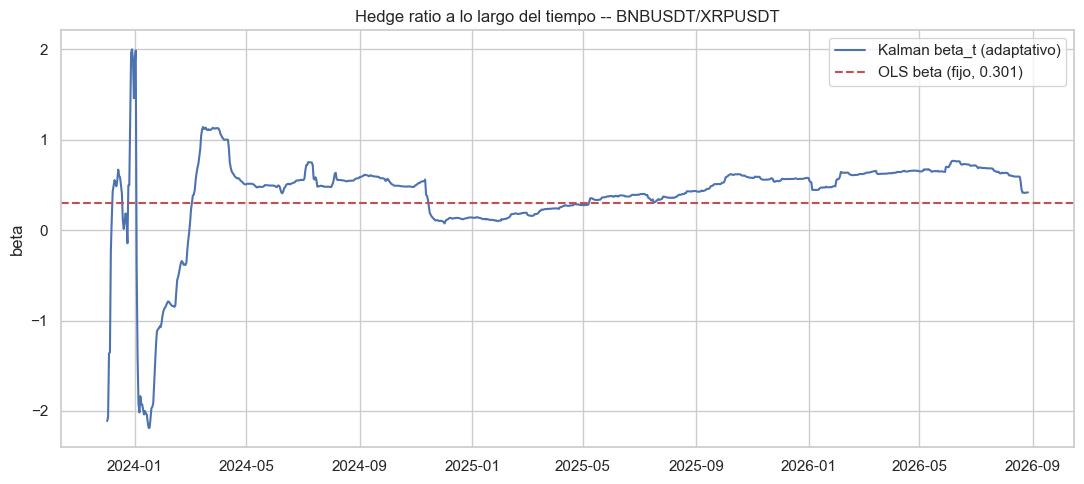

In [5]:
fig, ax = plt.subplots()
ax.plot(kf.beta.index, kf.beta, label="Kalman beta_t (adaptativo)", color="#4C72B0")
ax.axhline(hedge.beta, color="#C44E52", linestyle="--", label=f"OLS beta (fijo, {hedge.beta:.3f})")
ax.set_title(f"Hedge ratio a lo largo del tiempo -- {Y_SYMBOL}/{X_SYMBOL}")
ax.set_ylabel("beta")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Curva de equity: OLS vs. Kalman (neto de costos)

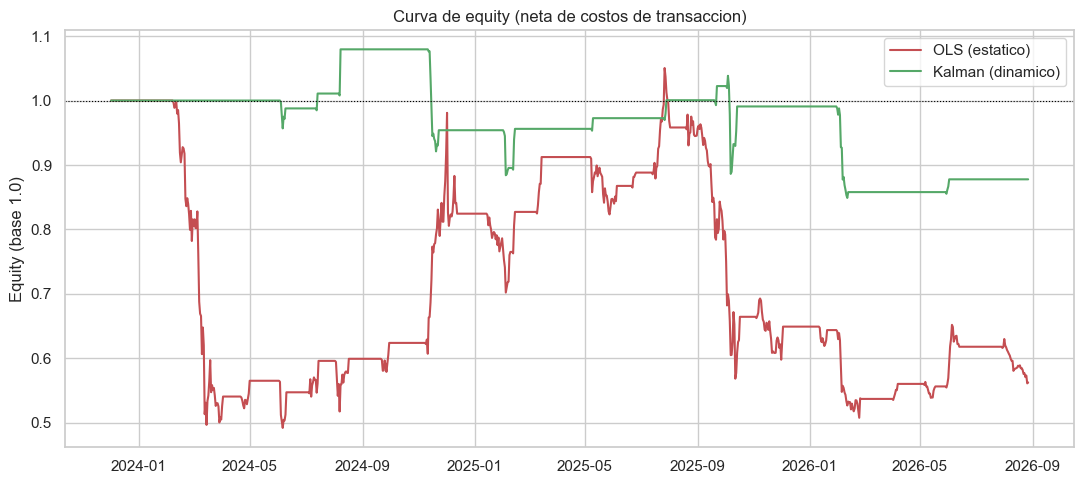

In [6]:
fig, ax = plt.subplots()
ax.plot(bt_ols.equity_curve.index, bt_ols.equity_curve, label="OLS (estatico)", color="#C44E52")
ax.plot(bt_kf.equity_curve.index, bt_kf.equity_curve, label="Kalman (dinamico)", color="#55A868")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Curva de equity (neta de costos de transaccion)")
ax.set_ylabel("Equity (base 1.0)")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Drawdown: OLS vs. Kalman

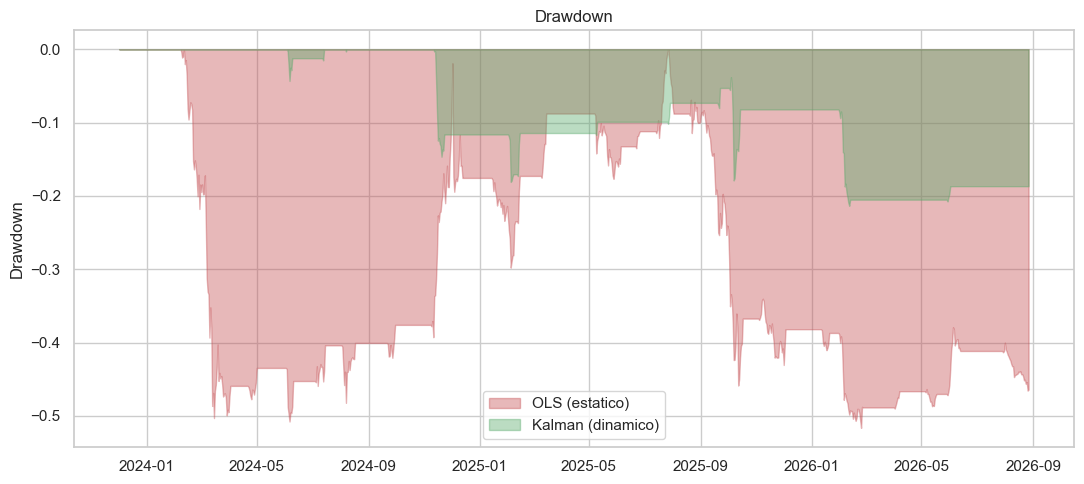

In [7]:
def drawdown_series(equity: pd.Series) -> pd.Series:
    return equity / equity.cummax() - 1

dd_ols = drawdown_series(bt_ols.equity_curve)
dd_kf = drawdown_series(bt_kf.equity_curve)

fig, ax = plt.subplots()
ax.fill_between(dd_ols.index, dd_ols, 0, color="#C44E52", alpha=0.4, label="OLS (estatico)")
ax.fill_between(dd_kf.index, dd_kf, 0, color="#55A868", alpha=0.4, label="Kalman (dinamico)")
ax.set_title("Drawdown")
ax.set_ylabel("Drawdown")
ax.legend()
fig.tight_layout()
plt.show()

**Lectura honesta**: el Kalman reduce sustancialmente tanto la pérdida total como el drawdown máximo frente al OLS estático, pero **ninguno de los dos métodos es rentable en esta ventana** -- el Sharpe anualizado sigue siendo negativo en ambos casos. Esto se reporta tal cual, no se retunea para fabricar un ganador.

## 7. Impacto de los costos de transacción (bruto vs. neto)

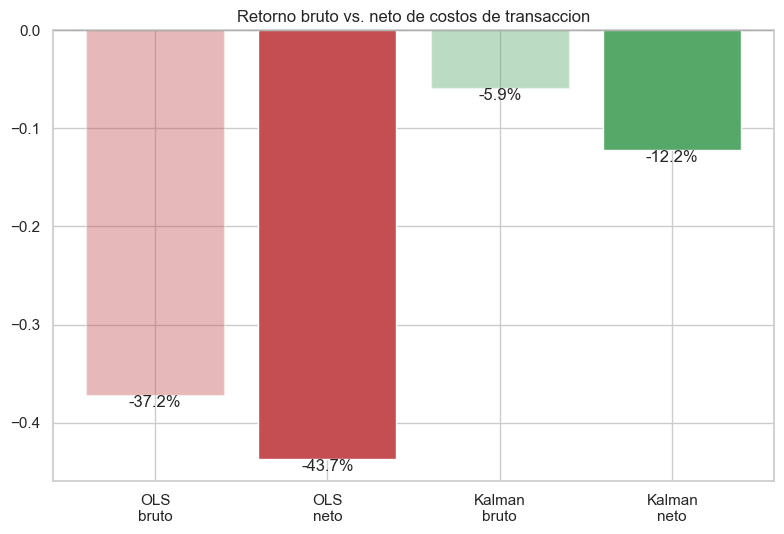

Costo total OLS: 11.10% (21 trades)
Costo total Kalman: 7.02% (13 trades)


In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["OLS\nbruto", "OLS\nneto", "Kalman\nbruto", "Kalman\nneto"]
values = [bt_ols.total_return_gross, bt_ols.total_return, bt_kf.total_return_gross, bt_kf.total_return]
colors = ["#C44E52", "#C44E52", "#55A868", "#55A868"]
alphas = [0.4, 1.0, 0.4, 1.0]
bars = ax.bar(labels, values, color=colors)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom" if v >= 0 else "top")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Retorno bruto vs. neto de costos de transaccion")
fig.tight_layout()
plt.show()

print(f"Costo total OLS: {bt_ols.total_transaction_cost:.2%} ({bt_ols.n_trades} trades)")
print(f"Costo total Kalman: {bt_kf.total_transaction_cost:.2%} ({bt_kf.n_trades} trades)")

## 8. Chequeo de cordura sintético: ¿el Kalman realmente seguiría un cambio de régimen?

Sobre datos reales no hay una "respuesta correcta" conocida para el hedge ratio -- así que este chequeo usa una serie **sintética con un cambio de régimen conocido** (beta=0.5 en la primera mitad, beta=1.5 en la segunda) para verificar directamente que el Kalman recupera ambos regímenes mientras el OLS, forzado a un único número para toda la serie, no puede.

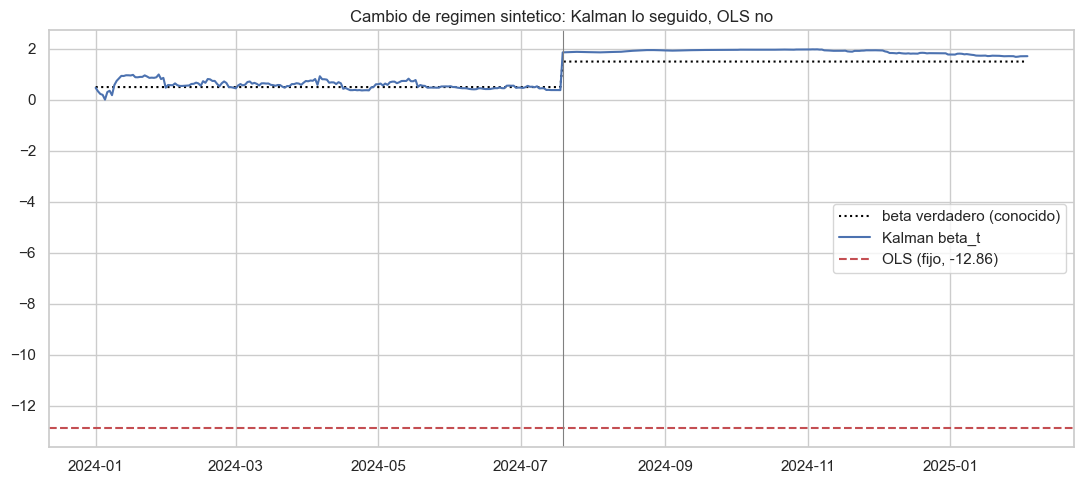

Beta Kalman, ultimos 50 dias del regimen 1 (verdadero=0.5): 0.463
Beta Kalman, ultimos 50 dias del regimen 2 (verdadero=1.5): 1.766
Beta OLS (un solo numero para las dos regimenes): -12.860


In [9]:
rng = np.random.default_rng(42)
n = 400
synthetic_x = pd.Series(np.cumsum(rng.normal(0, 0.01, n)) + 4.0, index=pd.date_range("2024-01-01", periods=n))
true_beta = np.where(np.arange(n) < 200, 0.5, 1.5)
synthetic_y = pd.Series(true_beta * synthetic_x.to_numpy() + rng.normal(0, 0.02, n), index=synthetic_x.index)

kf_synthetic = run_kalman_hedge_ratio(synthetic_y, synthetic_x)
ols_synthetic = estimate_hedge_ratio(synthetic_y, synthetic_x)

fig, ax = plt.subplots()
ax.plot(synthetic_x.index, true_beta, color="black", linestyle=":", label="beta verdadero (conocido)")
ax.plot(kf_synthetic.beta.index, kf_synthetic.beta, color="#4C72B0", label="Kalman beta_t")
ax.axhline(ols_synthetic.beta, color="#C44E52", linestyle="--", label=f"OLS (fijo, {ols_synthetic.beta:.2f})")
ax.axvline(synthetic_x.index[200], color="gray", linewidth=0.8)
ax.set_title("Cambio de regimen sintetico: Kalman lo seguido, OLS no")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Beta Kalman, ultimos 50 dias del regimen 1 (verdadero=0.5): {kf_synthetic.beta.iloc[150:200].mean():.3f}")
print(f"Beta Kalman, ultimos 50 dias del regimen 2 (verdadero=1.5): {kf_synthetic.beta.iloc[-50:].mean():.3f}")
print(f"Beta OLS (un solo numero para las dos regimenes): {ols_synthetic.beta:.3f}")

## 9. Conclusión

- El chequeo sintético confirma el mecanismo: cuando el verdadero hedge ratio cambia de régimen, el Kalman lo recupera en ambos tramos mientras el OLS, promediando sobre todo el período, da un número que no describe bien a ninguno de los dos.
- Sobre datos reales, el Kalman redujo la pérdida total y el drawdown máximo frente al OLS estático, pero ninguno de los dos métodos fue rentable en esta ventana -- un resultado honesto, no una estrategia ganadora fabricada.
- Los costos de transacción (fee + slippage asimétrico) empeoran ambos resultados de forma medible, no trivial -- ver §7.